In [2]:
import xarray as xr

In [3]:
era5_data = 'era5_out/'

In [4]:
ds_oper = xr.open_mfdataset(
    era5_data + "era5_sl_*_oper.nc",
    combine="by_coords",
    engine="netcdf4"
)

ds_wave = xr.open_mfdataset(
    era5_data + "era5_sl_*_wave.nc",
    combine="by_coords",
    engine="netcdf4"
)

In [5]:
ds_oper.data_vars

Data variables:
    u10      (valid_time, latitude, longitude) float32 770MB dask.array<chunksize=(744, 17, 17), meta=np.ndarray>
    v10      (valid_time, latitude, longitude) float32 770MB dask.array<chunksize=(744, 17, 17), meta=np.ndarray>
    u100     (valid_time, latitude, longitude) float32 770MB dask.array<chunksize=(744, 17, 17), meta=np.ndarray>
    v100     (valid_time, latitude, longitude) float32 770MB dask.array<chunksize=(744, 17, 17), meta=np.ndarray>

In [6]:
ds_wave.data_vars

Data variables:
    swh      (valid_time, latitude, longitude) float32 216MB dask.array<chunksize=(744, 9, 9), meta=np.ndarray>
    pp1d     (valid_time, latitude, longitude) float32 216MB dask.array<chunksize=(744, 9, 9), meta=np.ndarray>

In [7]:
ds = xr.merge([ds_oper, ds_wave])
ds.data_vars

/tmp/ipykernel_15810/2898229948.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'latitude' ('latitude',) The recommendation is to set join explicitly for this case.
  ds = xr.merge([ds_oper, ds_wave])
/tmp/ipykernel_15810/2898229948.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'longitude' ('longitude',) The recommendation is to set join explicitly for this case.
  ds = xr.merge([ds_oper, ds_wave])
/tmp/ipykernel_15810/2898229948.py:1: FutureWarning: In a future version of xarray the default value for c

Data variables:
    u10      (valid_time, latitude, longitude) float32 770MB dask.array<chunksize=(744, 17, 17), meta=np.ndarray>
    v10      (valid_time, latitude, longitude) float32 770MB dask.array<chunksize=(744, 17, 17), meta=np.ndarray>
    u100     (valid_time, latitude, longitude) float32 770MB dask.array<chunksize=(744, 17, 17), meta=np.ndarray>
    v100     (valid_time, latitude, longitude) float32 770MB dask.array<chunksize=(744, 17, 17), meta=np.ndarray>
    swh      (valid_time, latitude, longitude) float32 770MB dask.array<chunksize=(744, 9, 9), meta=np.ndarray>
    pp1d     (valid_time, latitude, longitude) float32 770MB dask.array<chunksize=(744, 9, 9), meta=np.ndarray>

In [8]:
# 56.5110° N, 3.5156° E

target_lat = 56.5110
target_lon = 3.5156

ds_point = ds.sel(longitude=target_lon, latitude=target_lat, method="nearest")

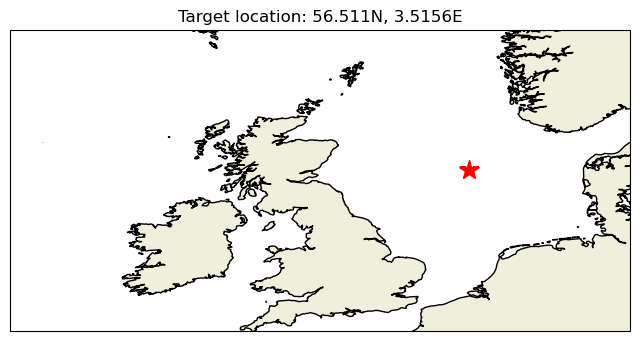

In [63]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(8, 6))
ax.set_extent([-15, 10, 50, 62])
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.plot(target_lon, target_lat, 'r*', markersize=15, transform=ccrs.PlateCarree())
ax.set_title(f"Target location: {target_lat}N, {target_lon}E")
plt.show()

In [9]:
import numpy as np

In [10]:
u10 = ds_point["u10"].values
v10 = ds_point["v10"].values
u100 = ds_point["u100"].values
v100 = ds_point["v100"].values
w10 = np.sqrt(u10**2 + v10**2)
w100 = np.sqrt(u100**2 + v100**2)

Hs = ds_point["swh"].values
Tp = ds_point["pp1d"].values

time = ds_point["valid_time"].values

In [11]:
import pandas as pd

In [12]:
df = pd.DataFrame(
    {
        "time": time,
        "w10": w10,
        "w100": w100,
        "Hs": Hs,
        "Tp": Tp,
    }
    )

In [13]:
df.set_index("time", inplace=True)

In [14]:
df

,w10,w100,Hs,Tp
time,,,,
1950-01-01 00:00:00,11.793207,13.590796,2.411764,6.957863
1950-01-01 01:00:00,11.492748,13.367449,2.388366,6.941750
1950-01-01 02:00:00,10.953833,12.764117,2.322796,6.924171
1950-01-01 03:00:00,10.448668,12.211603,2.234878,6.900734
1950-01-01 04:00:00,9.964745,11.706643,2.135756,6.870461
...,...,...,...,...
2025-12-31 19:00:00,15.156098,18.482771,3.666280,8.302101
2025-12-31 20:00:00,14.932158,18.226141,3.835622,8.411964
2025-12-31 21:00:00,15.508170,19.153120,4.021532,8.506203


In [15]:
df.head(25)

,w10,w100,Hs,Tp
time,,,,
1950-01-01 00:00:00,11.793207,13.590796,2.411764,6.957863
1950-01-01 01:00:00,11.492748,13.367449,2.388366,6.941750
1950-01-01 02:00:00,10.953833,12.764117,2.322796,6.924171
1950-01-01 03:00:00,10.448668,12.211603,2.234878,6.900734
1950-01-01 04:00:00,9.964745,11.706643,2.135756,6.870461
1950-01-01 05:00:00,9.425398,11.187981,2.037004,6.832863
1950-01-01 06:00:00,9.297925,11.113667,1.943858,6.784523
1950-01-01 07:00:00,9.025740,10.861617,1.865614,6.719093
1950-01-01 08:00:00,7.906920,9.545306,1.782902,6.636574


In [16]:
import matplotlib.pyplot as plt

<Axes: xlabel='time'>

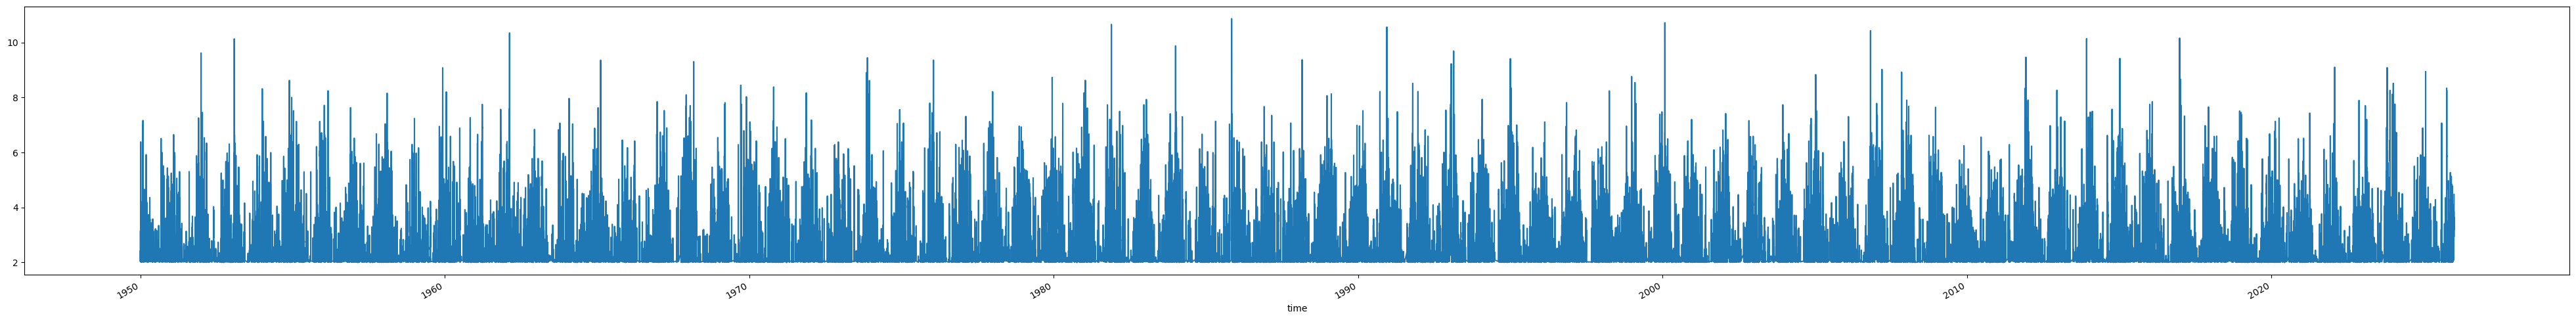

In [17]:
plt.figure(figsize=(50, 6))
df.Hs[df.Hs > 2].plot()

In [64]:
storm_mask = (df['Hs'] > 4) & (df['w10'] > 15)
storm_blocks = (storm_mask != storm_mask.shift()).cumsum()
storm_blocks = storm_blocks[storm_mask]

In [65]:
storm_peaks = df[storm_mask].groupby(storm_blocks)['Hs'].idxmax()
peak_times = storm_peaks.values
peak_df = df.loc[peak_times].sort_index()

peak_df

,w10,w100,Hs,Tp
time,,,,
1950-01-06 03:00:00,18.613314,22.992428,6.383548,10.103859
1950-01-15 19:00:00,15.109118,18.980011,4.189570,8.814308
1950-01-30 19:00:00,15.087785,17.513891,4.113005,8.735207
1950-01-30 21:00:00,15.015469,17.419310,4.066162,8.809425
1950-02-01 10:00:00,18.857763,23.426971,7.161613,10.964455
...,...,...,...,...
2025-12-02 05:00:00,16.100941,20.508190,4.843548,9.808449
2025-12-10 05:00:00,16.105040,20.967913,4.788312,9.541847
2025-12-10 23:00:00,15.437896,20.001308,4.139457,8.960793


In [66]:
independent_peaks = [peak_df.index[0]]
for t in peak_df.index[1:]:
    if t - independent_peaks[-1] > pd.Timedelta("48h"):
        independent_peaks.append(t)

independent_storms = peak_df.loc[independent_peaks]

In [67]:
independent_storms

,w10,w100,Hs,Tp
time,,,,
1950-01-06 03:00:00,18.613314,22.992428,6.383548,10.103859
1950-01-15 19:00:00,15.109118,18.980011,4.189570,8.814308
1950-01-30 19:00:00,15.087785,17.513891,4.113005,8.735207
1950-02-03 05:00:00,17.325554,22.641651,5.646832,9.300636
1950-02-17 03:00:00,15.446268,20.812908,4.557912,9.234718
...,...,...,...,...
2025-11-28 13:00:00,16.358486,21.120430,5.131826,9.991554
2025-12-02 05:00:00,16.100941,20.508190,4.843548,9.808449
2025-12-10 05:00:00,16.105040,20.967913,4.788312,9.541847


In [68]:
number_of_storms_per_year = {
    year: len(grp)
    for year, grp in independent_storms.groupby(independent_storms.index.year)
}

years  = np.array(list(number_of_storms_per_year.keys()))
counts = np.array(list(number_of_storms_per_year.values()))


In [69]:
hourly_coverage = df.groupby(df.index.year).size()
incomplete_years = hourly_coverage[hourly_coverage < 8700].index.tolist()
if incomplete_years:
    print(f"WARNING: possible incomplete data in years: {incomplete_years}")
    print("Storm counts for these years may be understated.")


In [70]:
from scipy.stats import linregress


In [71]:
slope, intercept, r, p_value, _ = linregress(years, counts)
trend = slope * years + intercept

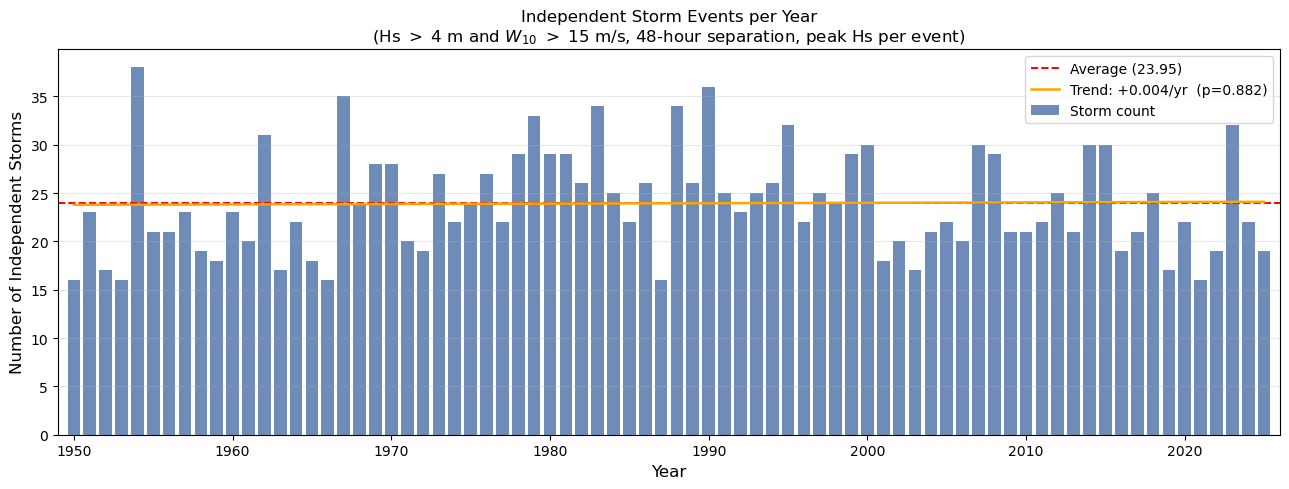

In [75]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.bar(years, counts, color="#4A6FA5", alpha=0.8, width=0.8, label="Storm count")

ax.axhline(counts.mean(), color="red", linestyle="--", linewidth=1.4,
           label=f"Average ({counts.mean():.2f})")

ax.plot(years, trend, color="orange", linewidth=1.8,
        label=f"Trend: {slope:+.3f}/yr  (p={p_value:.3f})")
for yr in incomplete_years:
    ax.axvline(yr, color="grey", linestyle=":", linewidth=1, alpha=0.7)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Number of Independent Storms", fontsize=12)
ax.set_title(
    "Independent Storm Events per Year\n"
    r"(Hs $>$ 4 m and $W_{10}$ $>$ 15 m/s, 48-hour separation, peak Hs per event)",
    fontsize=12
)
ax.legend(fontsize=10)
ax.set_xlim(years[0] - 1, years[-1] + 1)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


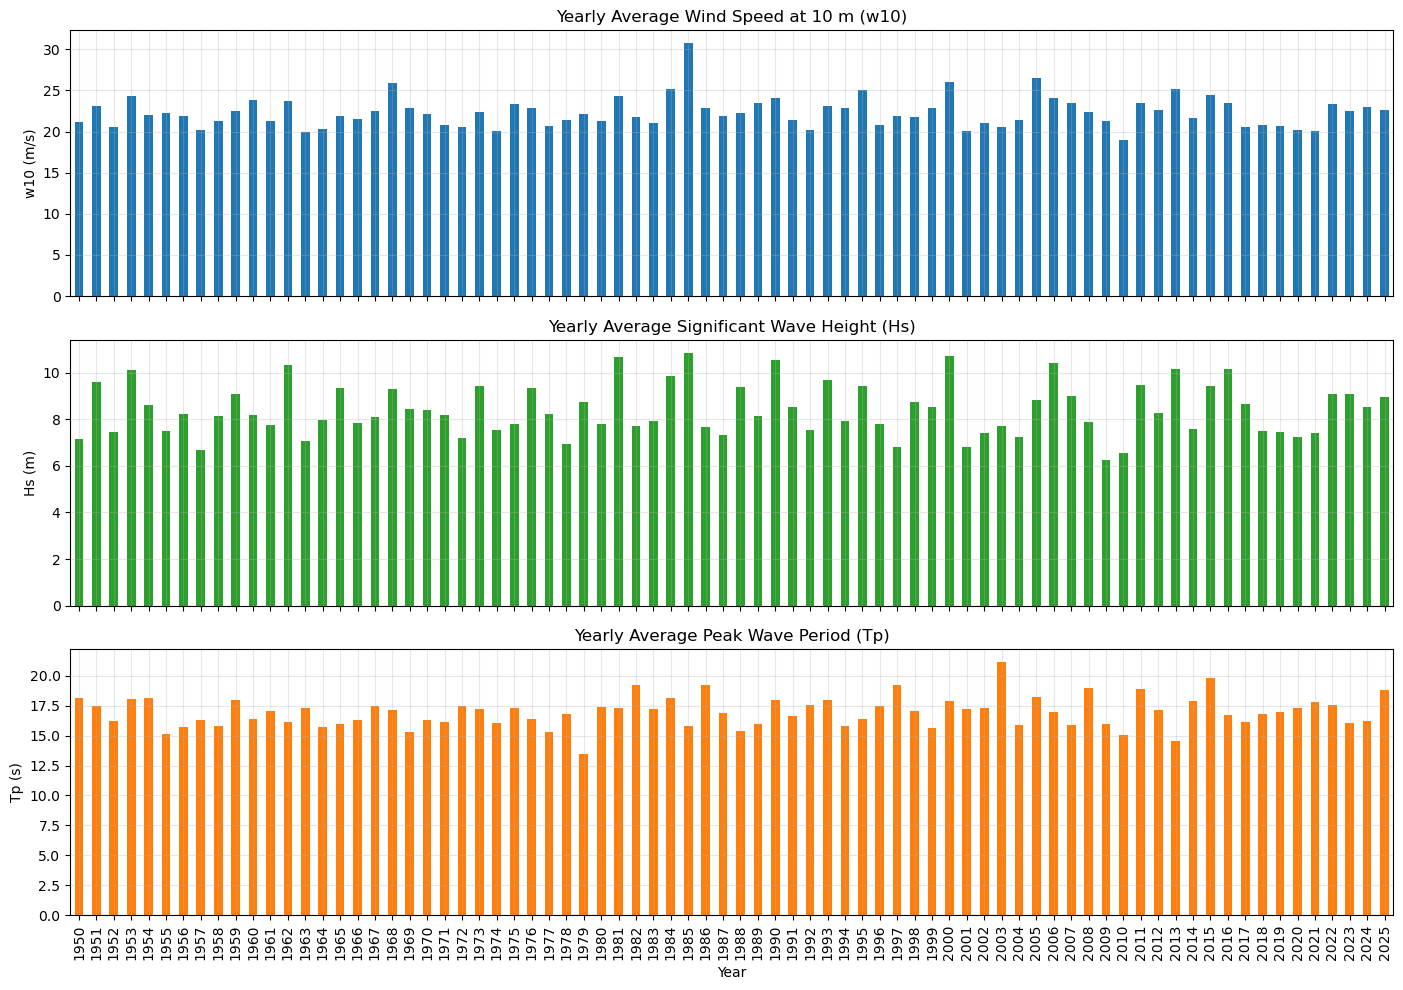

In [79]:
# yearly_avg = df[["w10", "Hs", "Tp"]].groupby(df.index.year).mean()
yearly_avg = df[["w10", "Hs", "Tp"]].groupby(df.index.year).max()


fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

yearly_avg["w10"].plot(ax=axes[0], color="tab:blue", linewidth=1.8, kind='bar')
axes[0].set_ylabel("w10 (m/s)")
axes[0].set_title("Yearly Average Wind Speed at 10 m (w10)")
axes[0].grid(alpha=0.3)

yearly_avg["Hs"].plot(ax=axes[1], color="tab:green", linewidth=1.8, kind='bar')
axes[1].set_ylabel("Hs (m)")
axes[1].set_title("Yearly Average Significant Wave Height (Hs)")
axes[1].grid(alpha=0.3)

yearly_avg["Tp"].plot(ax=axes[2], color="tab:orange", linewidth=1.8, kind='bar')
axes[2].set_ylabel("Tp (s)")
axes[2].set_title("Yearly Average Peak Wave Period (Tp)")
axes[2].set_xlabel("Year")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [73]:

print(f"\nTotal independent storm peaks: {len(independent_storms)}")
print(f"Years covered:                 {years[0]} - {years[-1]}")
print(f"Mean storms per year (T):      {counts.mean():.2f}")
print(f"Trend slope:                   {slope:+.4f} storms/year")
print(f"Trend p-value:                 {p_value:.4f} "
      f"({'significant' if p_value < 0.05 else 'not significant'} at 5%)")
print(f"\nT to use in Pf calculation:    {counts.mean():.2f}")
print(f"Pf (50-year return):           {1/(50 * counts.mean()):.6f}")
print(f"beta (50-year return):         "
      f"{float(__import__('scipy').stats.norm.ppf(1 - 1/(50 * counts.mean()))):.4f}")


Total independent storm peaks: 1820
Years covered:                 1950 - 2025
Mean storms per year (T):      23.95
Trend slope:                   +0.0042 storms/year
Trend p-value:                 0.8823 (not significant at 5%)

T to use in Pf calculation:    23.95
Pf (50-year return):           0.000835
beta (50-year return):         3.1433


In [74]:
print(f"Pf in 100 year return period: {1/(100 * counts.mean()):.6f}")
print(f"beta in 100 year return period: "
      f"{float(__import__('scipy').stats.norm.ppf(1 - 1/(100 * counts.mean()))):.4f}")  

Pf in 100 year return period: 0.000418
beta in 100 year return period: 3.3409


Hs - significant wave height  
Tp - peak wave period  
w10 - wind speed at 10m height  

The environmental contour method allows you to determine those combinations of wind and wave extremity that constitute an equal level of unliklihood/likelihood of occurence in a given return time, eg. combinations that a likely to occure once in 50 years or once in a 100 years.

The answer is not a single point, its a surface in a 3D space - what does that space (that 3D space represent? - is it all the possible combinations of wind and wave events that could occur?)

why we cant just pick the worst storms that happened and the most turbulent wind and the strong wind and design for that?

1. the combination produced will be extremely rare we massively over design
2. this would be under the wrongful assumption there is no relationship between the different parameters, but there is. 

to define equally rare we need a number that measures it.
enter Pf and Beta.

Pf is the exceedance probability per storm
we need to construct the probability value for a storm event that is so rare it happens only once in some number of years, say 50 or 100. to calculate that, we first look through the data, get the storm data over the years - has the trend stayed stable over the decades? - and obtain the average number of storms that occur yearly and then multiple that by the number of years we are looking at to get the estimates number of storms that would occur in that time range. then we define the exceedance proabability as the probability of 1 out of the total number of storms that occur with that period of time.

Beta refers to converting the probability to distance
The conversion is done using the standard normal distribution, and beta represents the number of standard devaitions from the mean.

beta = phi-inverse(1-Pf) 

ie, the number of standard deviations away from the  mean that corresponds to a probability of the a storm of rarity Pf not happening.

The U-space or the 3d space.
this space needs to be constructed frist before the contour can be drawn within it.

we construct it using the values we have for Hs, Tp, W10 - variables with different scales and units

we need to convert these variables into a format of the same unit, which is the number of standard deviations from the mean.


oh and BTW.

Over engineering for an event that has a probability to occur once in 10,000 years is an economic nightmare, you waste money and the wind energy generation ceases to be worth it.
The environmental contour method exists precisely to find the minimum sufficient design condition...not the safest possible, but the correctly calibrated one.
The contour is how you find combinations that are genuinely extreme and physically realistic and correspond exactly to your chosen return period. Not too conservative, not too lenient.

Why over-designing is bad
You said: if it's foolproof, why is that bad?
Because engineering is not just physics. It is economics.
A wind turbine foundation in the North Sea costs tens of millions of euros. The steel in the monopile, the installation vessel, the marine operations — all of that scales directly with how strong you make the structure. If you design for a 10,000-year event when you only needed a 50-year event, your foundation might need to be twice as thick, twice as heavy, twice as expensive.
Now multiply that across 200 turbines in a wind farm. You have just spent hundreds of millions of euros of extra steel guarding against a combination of conditions that will essentially never occur in the lifetime of the farm. That money could have built another wind farm entirely.
Over-design does not just waste money. It makes offshore wind less economically competitive against fossil fuels. In a world trying to decarbonise, that has real consequences.
The environmental contour method exists precisely to find the minimum sufficient design condition — not the safest possible, but the correctly calibrated one.

Why picking the worst of each variable does not eliminate the need for a contour
You said: if I already found the worst Hs, worst Tp, worst U10 — I have my design conditions. Why do I need a contour at all?
Here is the flaw in that logic. When you say "worst Hs ever recorded" you mean the single most extreme wave height in your 75-year ERA5 record. Maybe that was 14m, during Storm X in January 1993.
Now ask: what was the wind speed during that exact storm? Probably very high — maybe 25 m/s. But was it the highest wind speed ever recorded? Almost certainly not. The highest wind speed might have been during a different storm entirely, where waves were only 8m.
And the longest wave period ever? That might have been during a swell event with almost no wind at all — calm conditions after a distant Atlantic storm.
So the worst Hs, worst Tp, and worst U10 each came from three completely different storms. Combining them means you are designing for a storm that has simultaneously the waves of January 1993, the wind of some other event, and the wave period of a calm swell — a storm that has never existed and almost certainly never will.
That combination is not a 50-year event. It is not even a 1000-year event. It is essentially physically impossible given how the atmosphere and ocean actually work together.
The contour is how you find combinations that are genuinely extreme and physically realistic and correspond exactly to your chosen return period. Not too conservative, not too lenient.

In [83]:
df[["w10", "Hs", "Tp"]].values

array([[11.793207 ,  2.4117641,  6.957863 ],
       [11.492748 ,  2.3883657,  6.9417496],
       [10.953833 ,  2.3227959,  6.9241714],
       ...,
       [15.50817  ,  4.021532 ,  8.506203 ],
       [16.84127  ,  4.273144 ,  8.716652 ],
       [15.918493 ,  4.4723387,  9.116554 ]],
      shape=(666216, 3), dtype=float32)

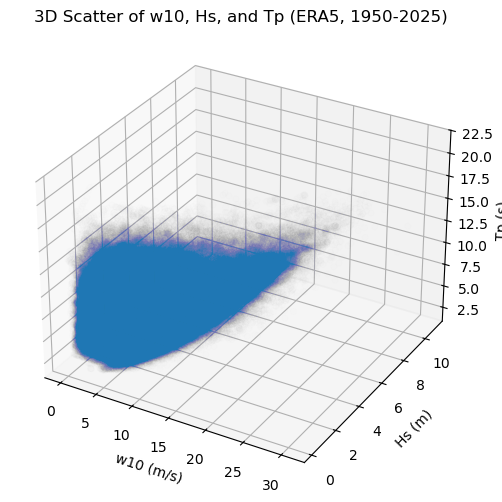

In [115]:
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df["w10"], df["Hs"], df["Tp"], marker='o', alpha=0.005)
ax.set_xlabel("w10 (m/s)")
ax.set_ylabel("Hs (m)")
ax.set_zlabel("Tp (s)")
ax.set_title("3D Scatter of w10, Hs, and Tp (ERA5, 1950-2025)")
plt.show()

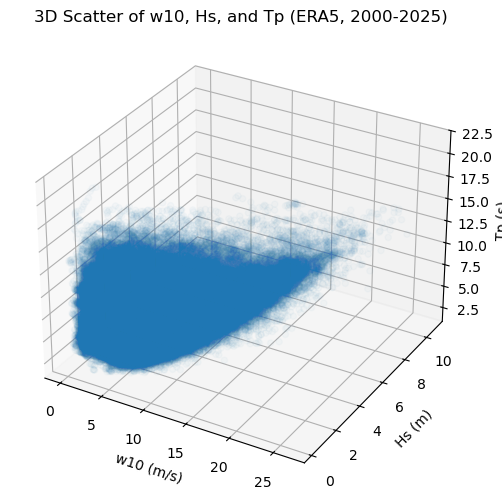

In [114]:
df_2000s = df[df.index.year >= 2000]
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df_2000s["w10"], df_2000s["Hs"], df_2000s["Tp"], marker='o', alpha=0.025)
ax.set_xlabel("w10 (m/s)")
ax.set_ylabel("Hs (m)")
ax.set_zlabel("Tp (s)")
ax.set_title("3D Scatter of w10, Hs, and Tp (ERA5, 2000-2025)")
plt.show()

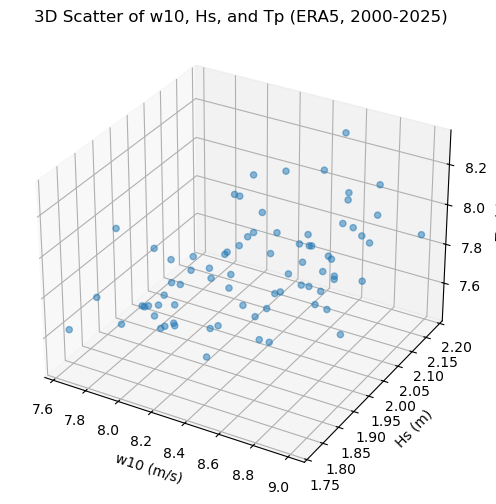

In [ ]:
df_yrly_avg = df.groupby(df.index.year).mean()
df_yrly_avg
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df_yrly_avg["w10"], df_yrly_avg["Hs"], df_yrly_avg["Tp"], marker='o', alpha=0.5)
ax.set_xlabel("w10 (m/s)")
ax.set_ylabel("Hs (m)")
ax.set_zlabel("Tp (s)")
ax.set_title("3D Scatter of w10, Hs, and Tp (ERA5, 1950-2025)")
plt.show()

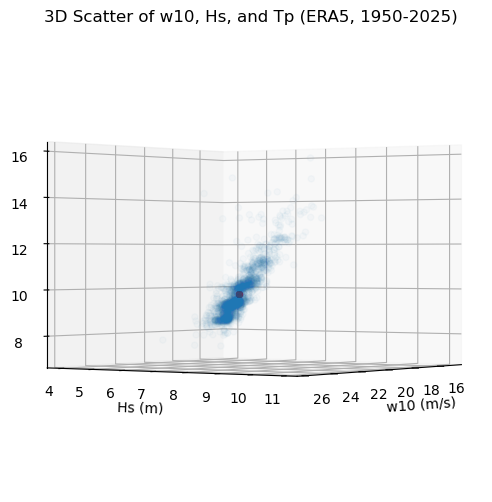

In [113]:
# df_storm_peaks = df.loc[peak_times]

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
# orientation
azim = 35
elev = 0
ax.view_init(elev=elev, azim=azim,)

ax.scatter(independent_storms["w10"], independent_storms["Hs"], independent_storms["Tp"], marker='o', alpha=0.025)
# average independent storm peaks
ax.scatter(independent_storms["w10"].mean(), independent_storms["Hs"].mean(), independent_storms["Tp"].mean(),
           color="red", marker='o', s=20, label="Average Independent Storm Peaks")

ax.set_xlabel("w10 (m/s)")
ax.set_ylabel("Hs (m)")
ax.set_zlabel("Tp (s)")
ax.set_title("3D Scatter of w10, Hs, and Tp (ERA5, 1950-2025)")
plt.show()

In [94]:
df_storm_peaks
independent_storms

,w10,w100,Hs,Tp
time,,,,
1950-01-06 03:00:00,18.613314,22.992428,6.383548,10.103859
1950-01-15 19:00:00,15.109118,18.980011,4.189570,8.814308
1950-01-30 19:00:00,15.087785,17.513891,4.113005,8.735207
1950-02-03 05:00:00,17.325554,22.641651,5.646832,9.300636
1950-02-17 03:00:00,15.446268,20.812908,4.557912,9.234718
...,...,...,...,...
2025-11-28 13:00:00,16.358486,21.120430,5.131826,9.991554
2025-12-02 05:00:00,16.100941,20.508190,4.843548,9.808449
2025-12-10 05:00:00,16.105040,20.967913,4.788312,9.541847


In [99]:
# average storm peak conditions
independent_storms.mean()

w10     16.630795
w100    20.953415
Hs       5.135480
Tp       9.699768
dtype: float32

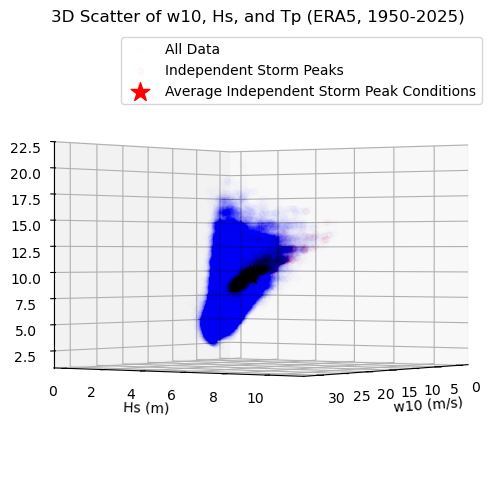

In [116]:
# blue dots all data, red dots independent storm peaks, red star average independent storm peak conditions

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
# orientation
azim = 35
elev = 0
ax.view_init(elev=elev, azim=azim,)

ax.scatter(df["w10"], df["Hs"], df["Tp"], color="blue", marker='o', alpha=0.005, label="All Data")

ax.scatter(independent_storms["w10"], independent_storms["Hs"], independent_storms["Tp"], color="red", marker='o', alpha=0.025, label="Independent Storm Peaks")

ax.scatter(independent_storms["w10"].mean(), independent_storms["Hs"].mean(), independent_storms["Tp"].mean(),
           color="red", marker='*', s=200, label="Average Independent Storm Peak Conditions")

ax.set_xlabel("w10 (m/s)")
ax.set_ylabel("Hs (m)")
ax.set_zlabel("Tp (s)")
ax.set_title("3D Scatter of w10, Hs, and Tp (ERA5, 1950-2025)")
ax.legend()
plt.show()  